# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [218]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [219]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [220]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/mit_idss/Project1/Customer_Personality_Segmentation.csv", sep="\t")

In [221]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [222]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [223]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [224]:
# Calculate the average household income
avg_income = data['Income'].mean()
avg_income

np.float64(52247.25135379061)

##### **Observations:**
- the average household income in the dataset is approximately $52,247
- this value represents the overall financial capacity of customers and will strongly influence their spending behavior and cluster segmentation.

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [225]:
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [226]:
data['Income'].fillna(data['Income'].median(), inplace=True)
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


##### **Observations:**
- dataset originally contained 24 missing values in the Income column
- since Income is a continuous variable and important for clustering, the median income was used to impute the missing values.
- after imputation, the dataset has no missing values in any column (isnull().sum() = 0).
- using the median is appropriate here because it is robust to outliers and keeps the overall income distribution balanced

#### **Question 4**: Are there any duplicates in the data?





In [227]:
# Check for duplicate rows in the dataset
duplicates_count = data.duplicated().sum()
duplicates_count

np.int64(0)

In [228]:
# If there are any duplicates, remove them
if duplicates_count > 0:
    data = data.drop_duplicates()

##### **Observations:**
- A check for duplicate rows in the dataset returned 0 duplicates
- Since there were no duplicate records, no rows were removed
- This ensures that the dataset contains only unique customer entries

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

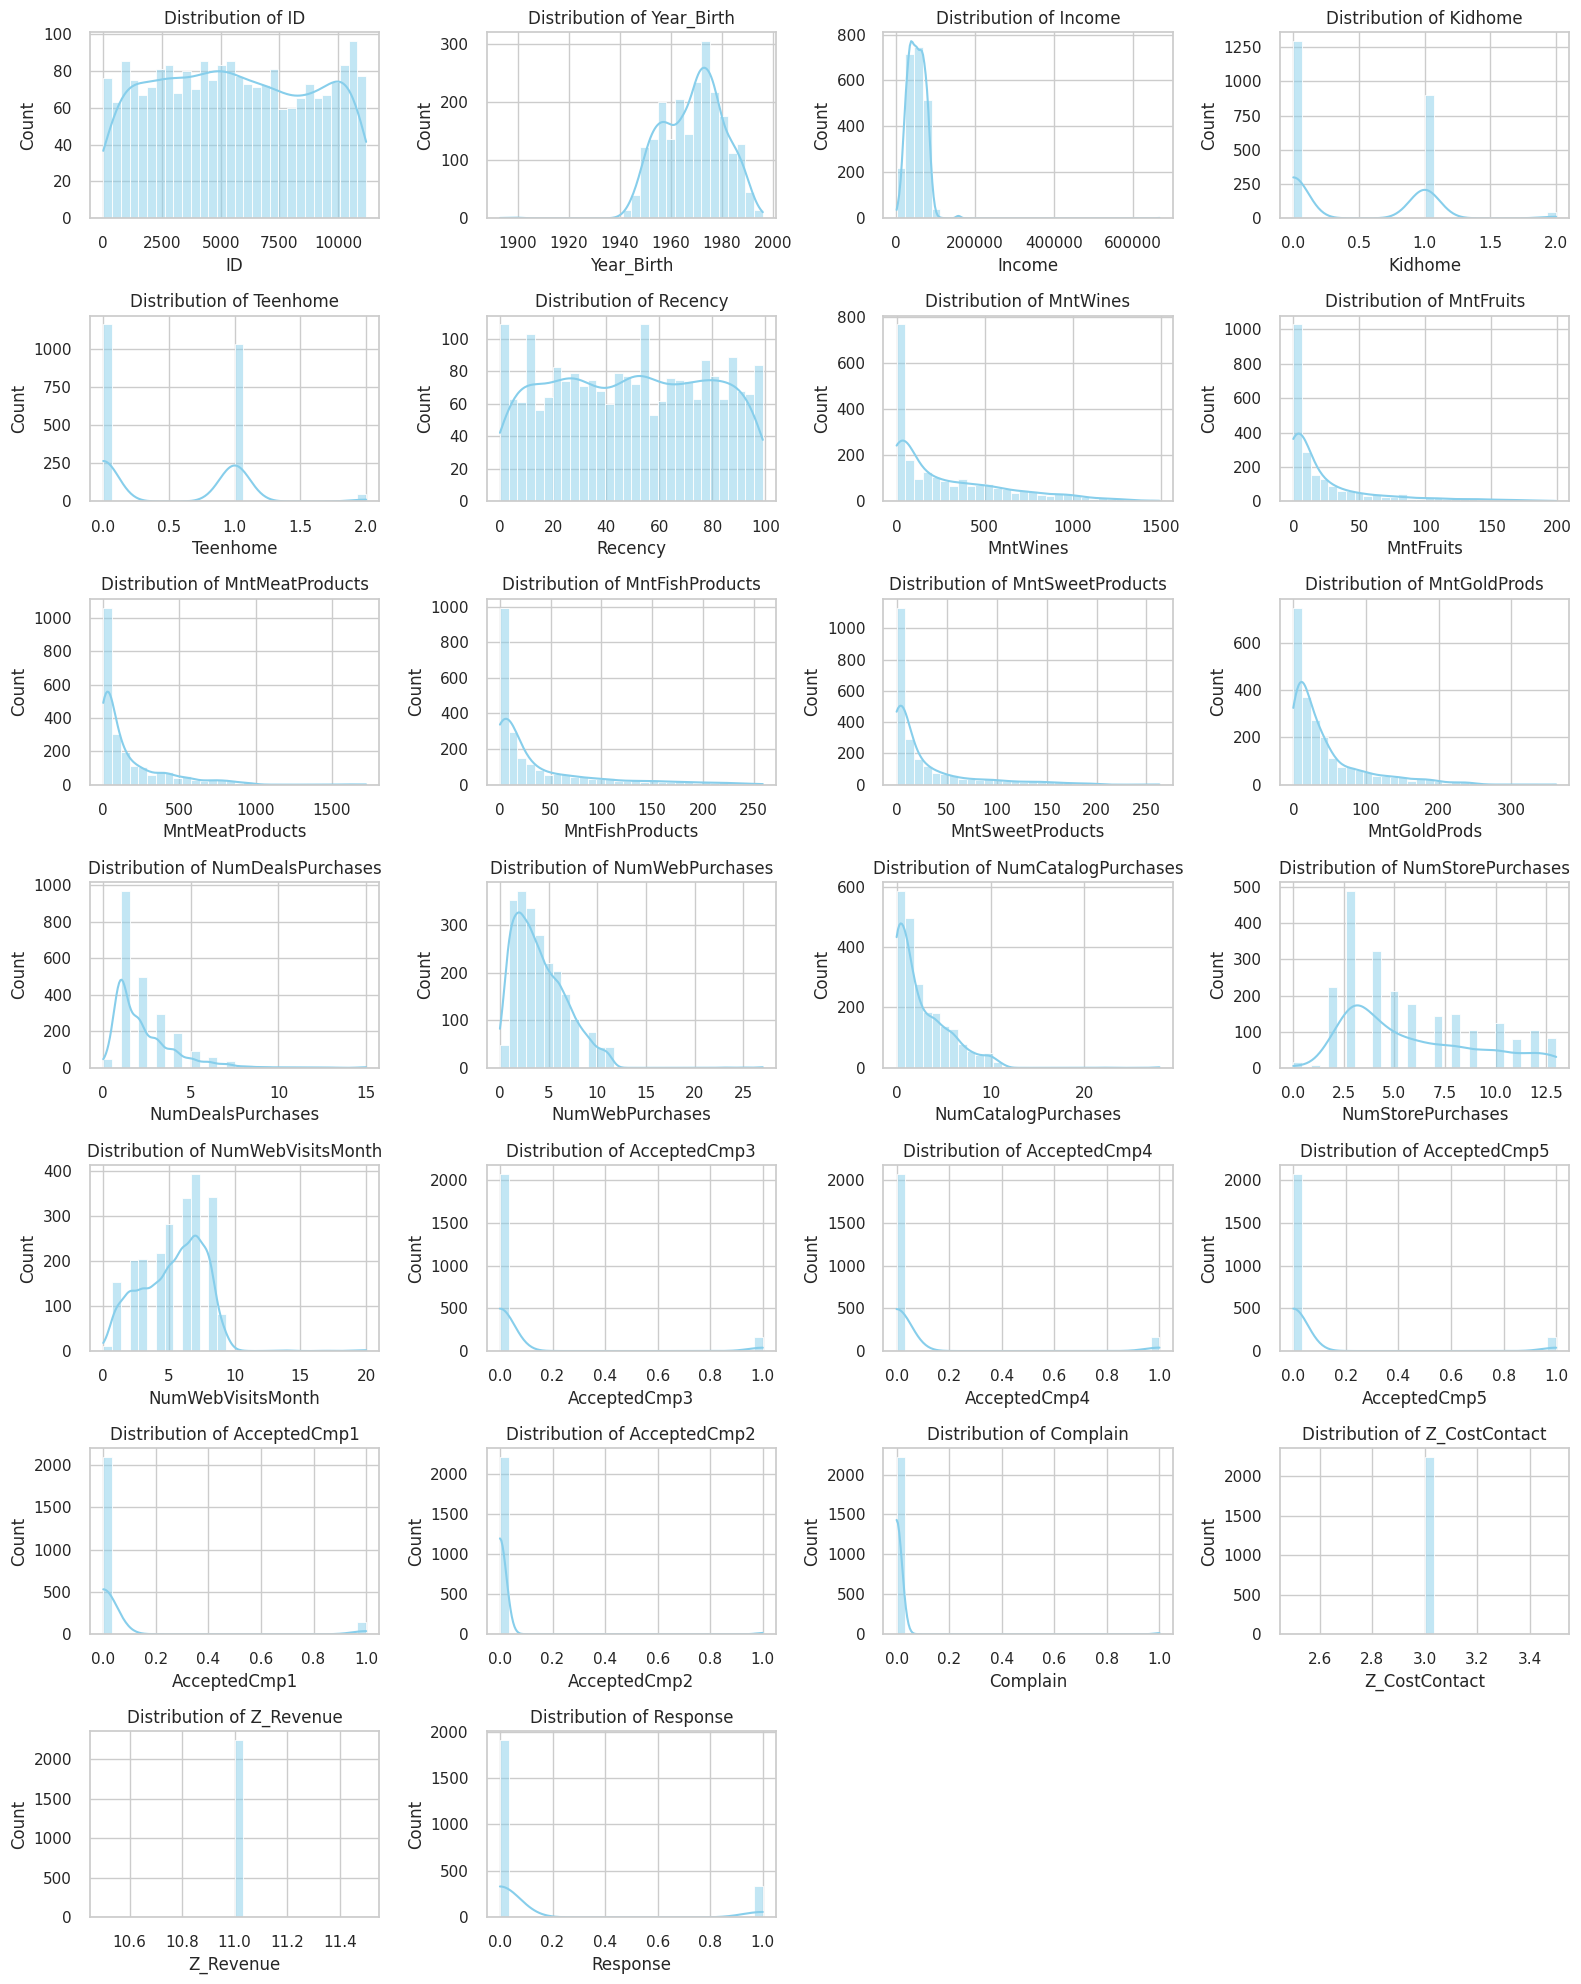

In [229]:
# List numeric columns
num_cols = data.select_dtypes(include=['int64','float64']).columns

# Histograms
plt.figure(figsize=(16, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//4 + 1, 4, i)
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


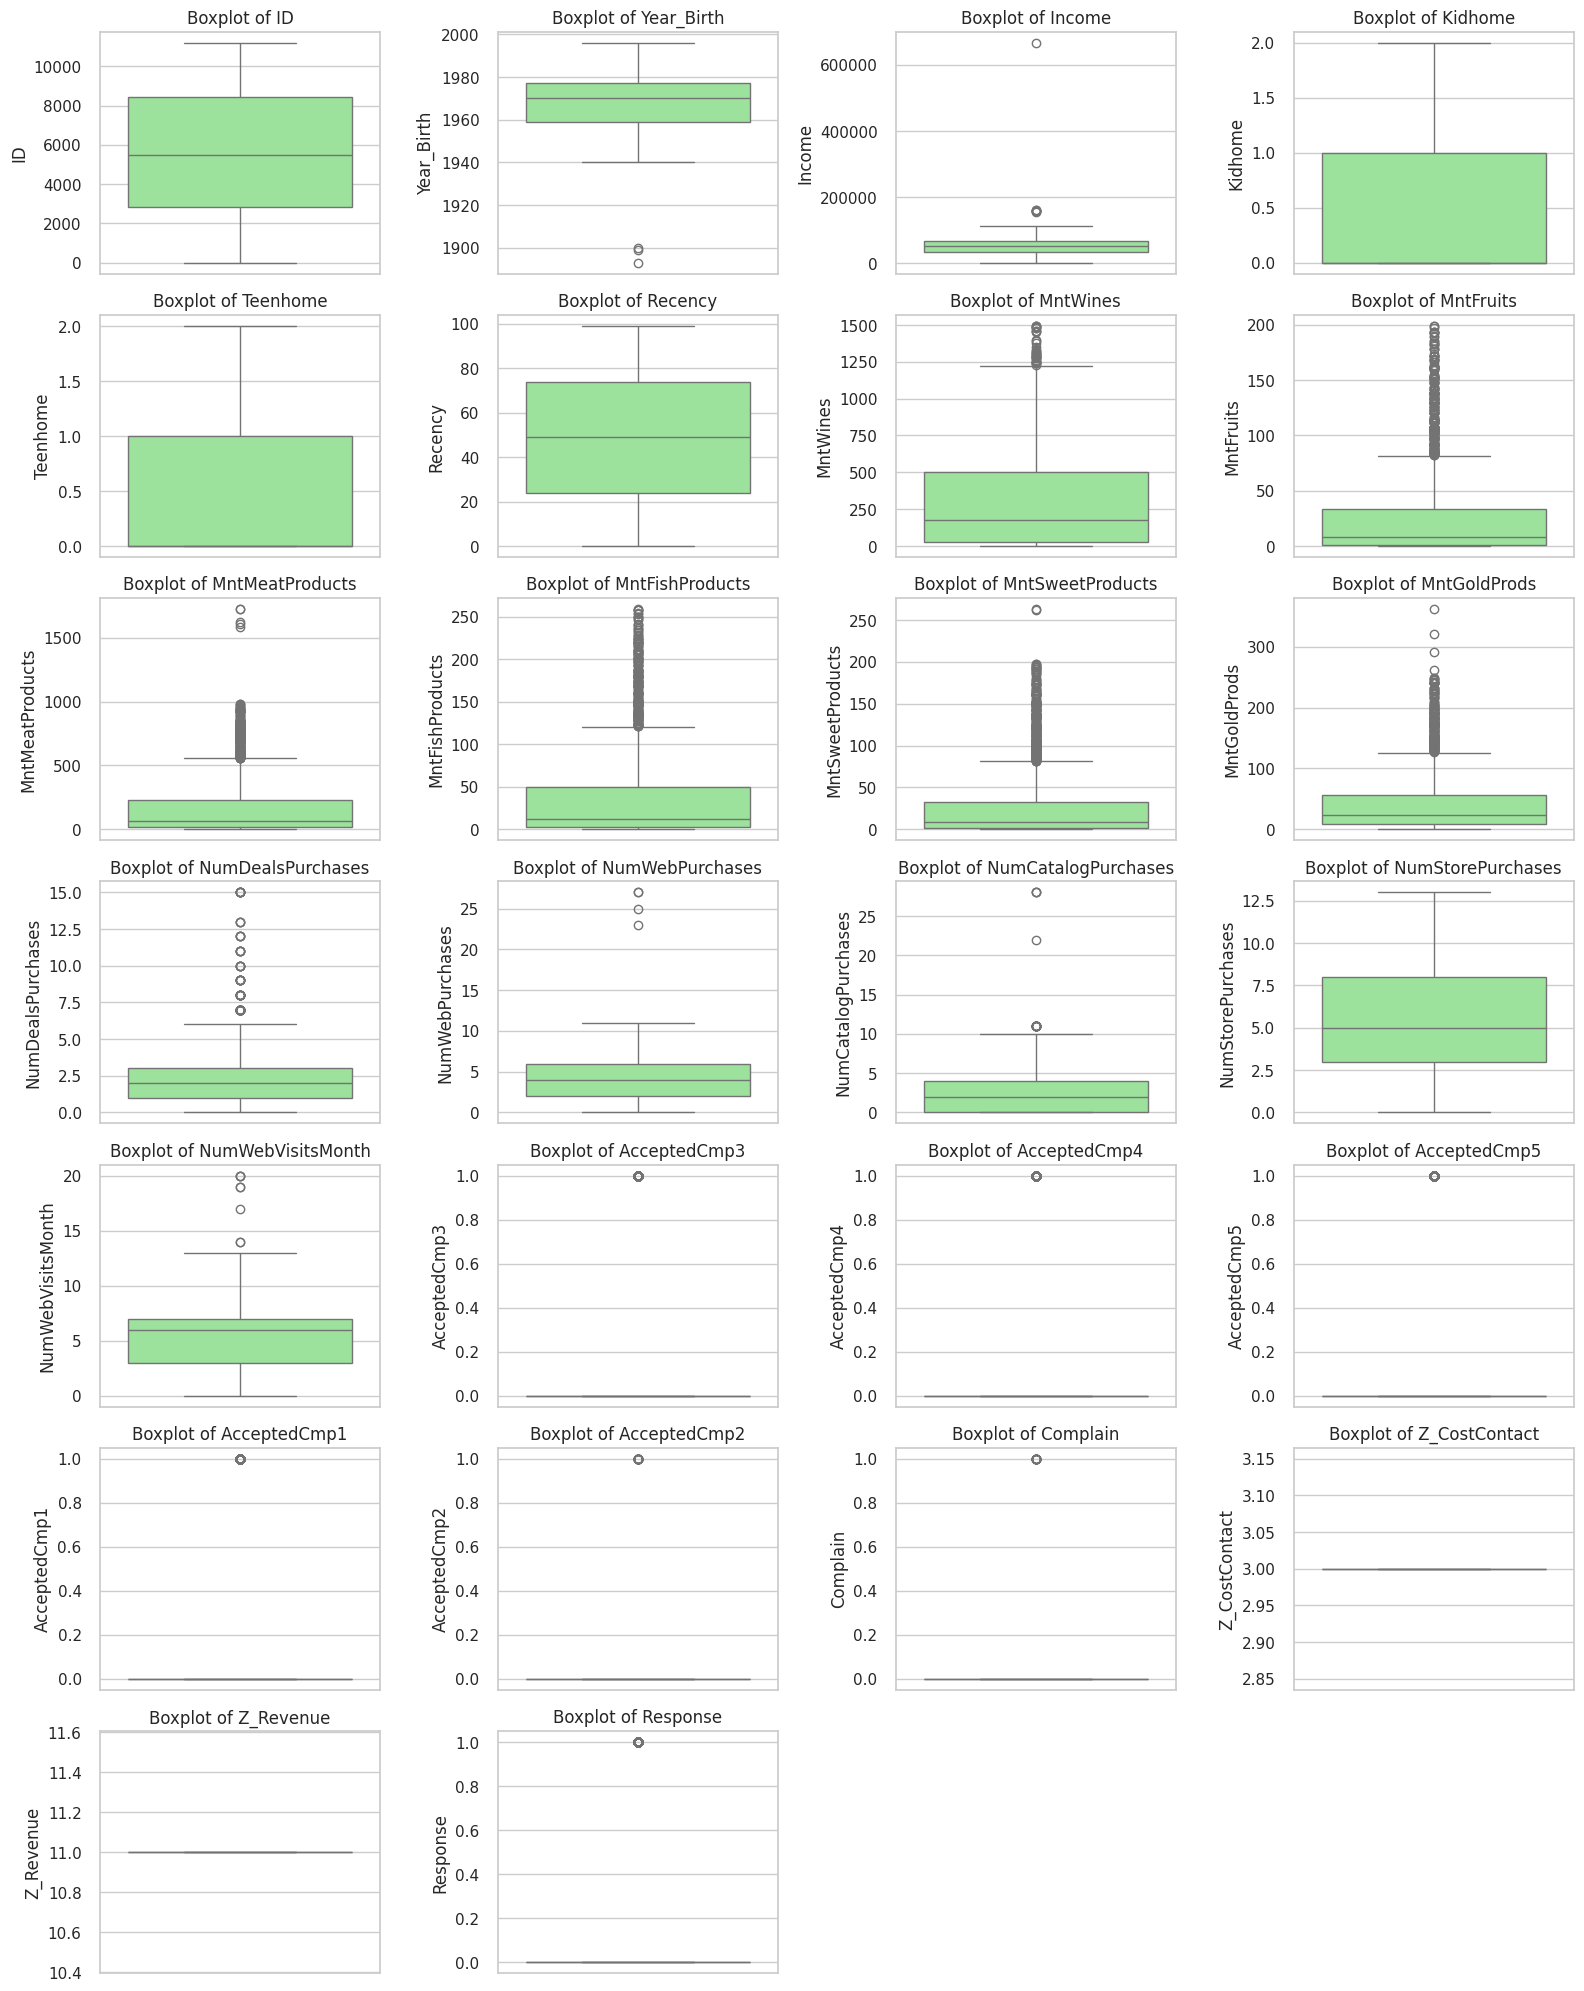

In [230]:
# Boxplots
plt.figure(figsize=(16, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//4 + 1, 4, i)
    sns.boxplot(y=data[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

##### **Observations:**

### 1. Income
- Distribution is right-skewed with most households earning below 100,000
- Several extreme outliers exist (above 200,000)
- Median is lower than the mean, confirming skewness

### 2. Year_Birth
- Most customers were born between 1940 and 1990
- A few outliers exist (very old >100 years, very young <20 years), likely due to data entry errors

### 3. Recency
- Appears uniformly distributed from 0 to 100
- Customers are evenly spread in terms of days since their last purchase

### 4. Spending Variables
*(MntWines, MntFruits, MntMeatProducts, MntFishProducts,
MntSweetProducts, MntGoldProds)*
- All variables are heavily right-skewed
- Majority of customers spend very little; a small group spends excessively
- Outliers are especially notable in Wine and Meat products

### 5. Purchase Behavior Variables

*(NumDealsPurchases, NumWebPurchases, NumCatalogPurchases,
NumStorePurchases, NumWebVisitsMonth)*
- Skewed toward low values (most customers make few purchases)
- Outliers present, showing a small number of very active buyers
- `NumWebVisitsMonth` peaks at 6-10 visits, showing regular but moderate browsing

### 6. Kidhome & Teenhome

-   Most households have 0-1 children teenagers
-   Very few have 2, resulting in imbalanced distributions

### 7. Campaign Variables

*(AcceptedCmp1-5, Response)*
- Strongly imbalanced binary variables
- Very few campaign acceptances, indicating low marketing effectiveness

### 8. Complain

- Almost all customers have no complaints (0)
-   Only a negligible number reported a complaint.

### 9. Z_CostContact & Z_Revenue

- Both are constant values across all rows



### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

In [231]:
# 1) Convert date to numeric tenure
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], errors='coerce')
data['Customer_Tenure_Days'] = (data['Dt_Customer'].max() - data['Dt_Customer']).dt.days

In [232]:
# 2) Drop obvious constants (no variance to break heatmaps / add noise)
constant_cols = [c for c in ['Z_CostContact','Z_Revenue'] if c in data.columns]
data_wo_constants = data.drop(columns=constant_cols)

In [233]:
# 3) Build a numeric-only frame for correlations
num_df = data_wo_constants.select_dtypes(include=[np.number])

In [234]:
# sanity: ensure we still have variance
num_df = num_df.loc[:, num_df.nunique() > 1]

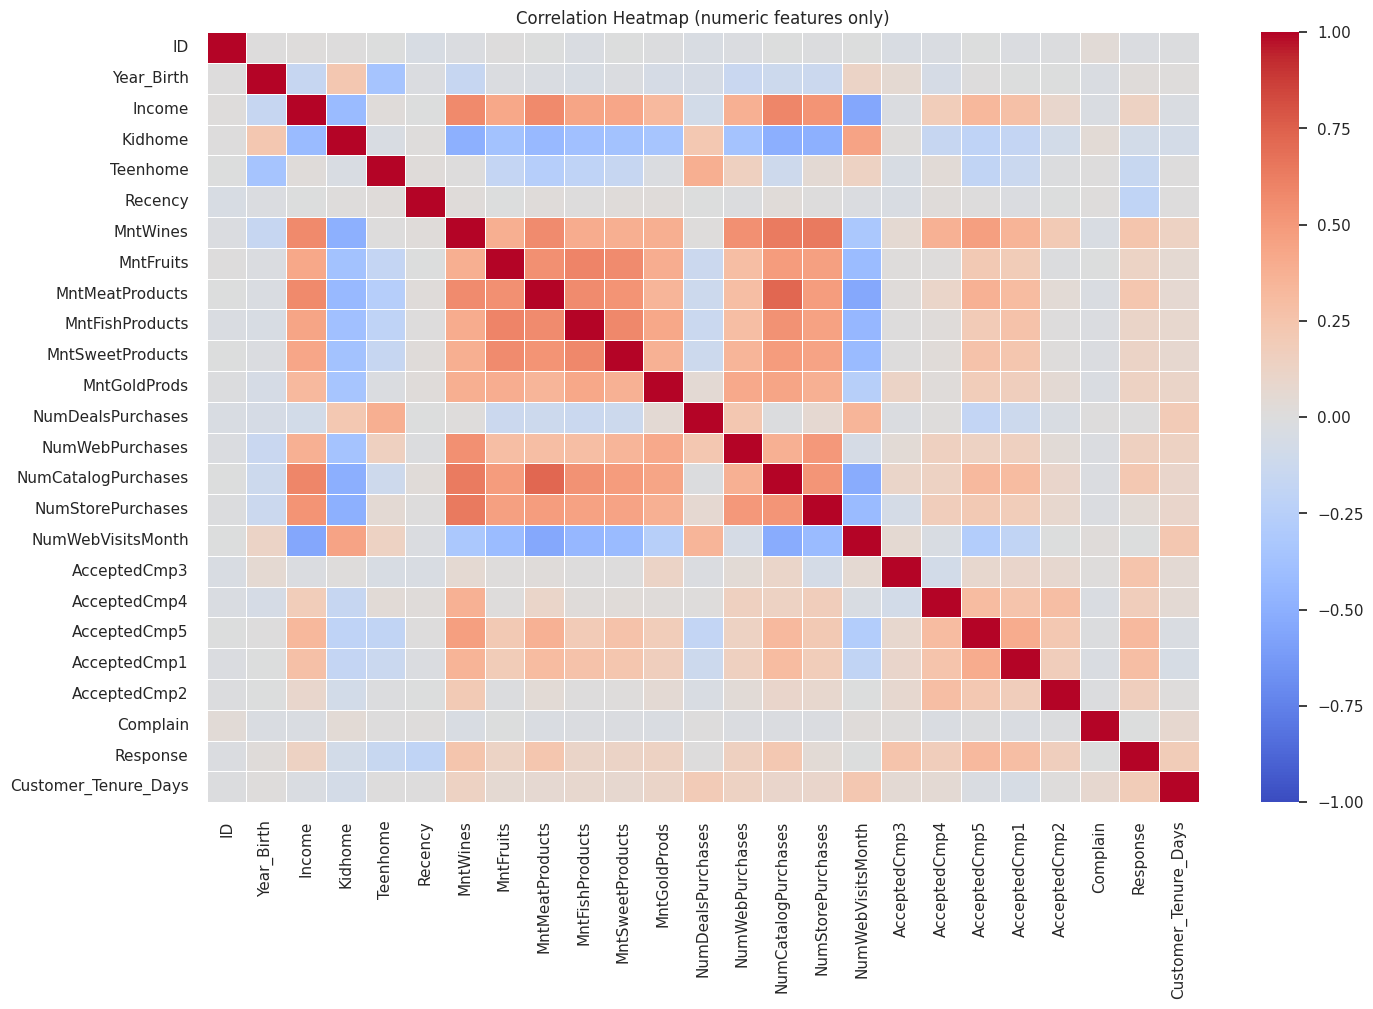

In [235]:
# 4) Correlation heatmap
plt.figure(figsize=(16,10))
corr = num_df.corr()
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap (numeric features only)")
plt.show()

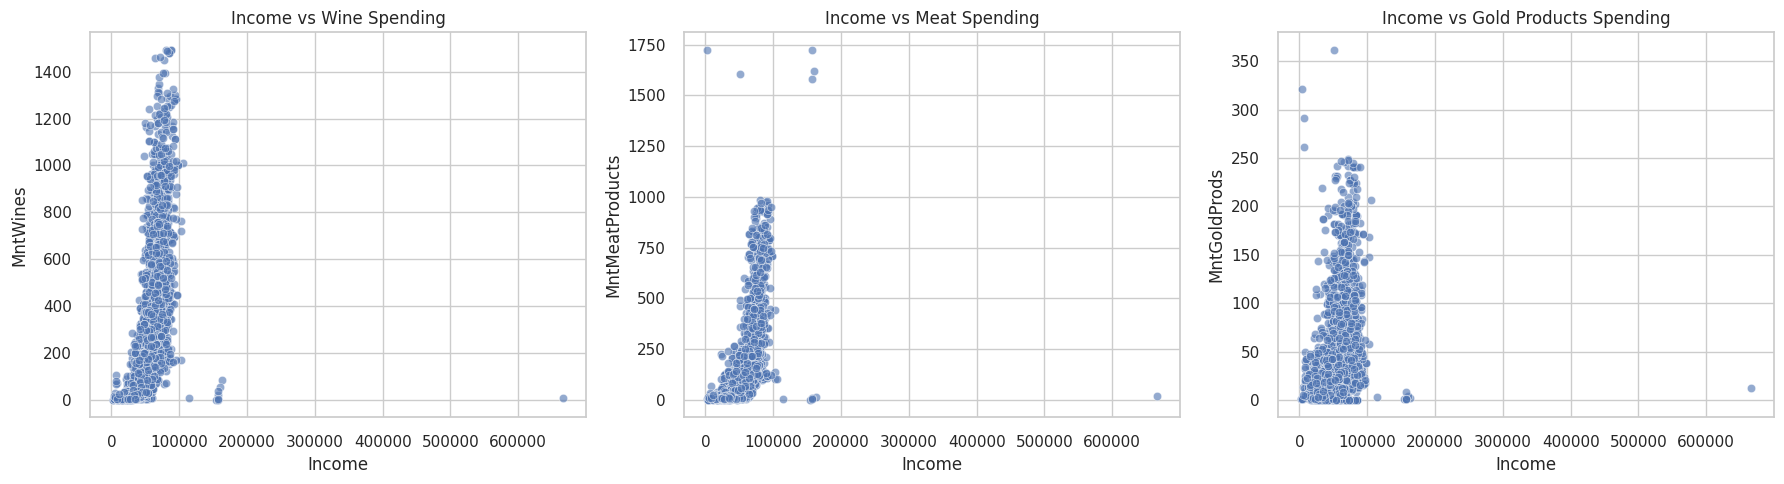

In [236]:
# 5) A few multivariate relationship plots
# Income vs key spend categories
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.scatterplot(x='Income', y='MntWines', data=data, ax=axes[0], alpha=0.6)
axes[0].set_title('Income vs Wine Spending')

sns.scatterplot(x='Income', y='MntMeatProducts', data=data, ax=axes[1], alpha=0.6)
axes[1].set_title('Income vs Meat Spending')

sns.scatterplot(x='Income', y='MntGoldProds', data=data, ax=axes[2], alpha=0.6)
axes[2].set_title('Income vs Gold Products Spending')

plt.tight_layout()
plt.show()

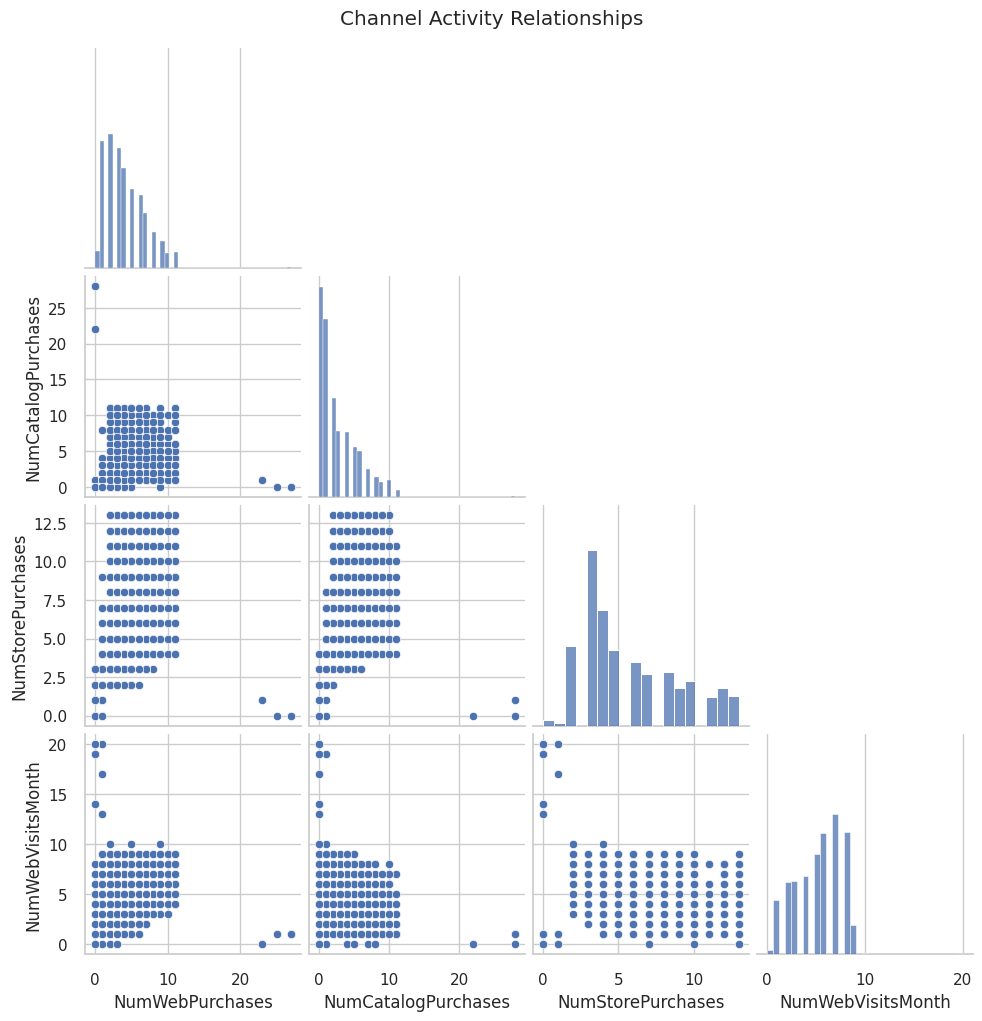

In [237]:
# Channel activity inter-relations
cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']

# plot pairplot
sns.pairplot(data[cols], corner=True, diag_kind='hist')
plt.suptitle('Channel Activity Relationships', y=1.02)
plt.show()


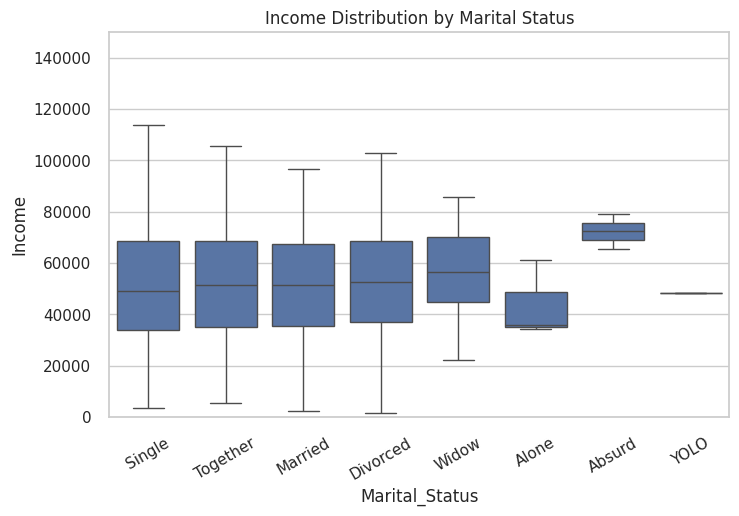

In [238]:
# Income by marital status (multivariate: category vs numeric)
plt.figure(figsize=(8,5))
sns.boxplot(x='Marital_Status', y='Income', data=data)
plt.xticks(rotation=30)
plt.ylim(0, 150000)
plt.title('Income Distribution by Marital Status')
plt.show()

##### **Observations:**
- Spending variables (Wine, Meat, Gold) are positively correlated; big spenders usually buy more in many categories.

- Income is linked with spending: higher income and higher spending. Still, some high-income clients spend little, and some low-income spend a lot (outliers).

- Channels (web, catalog, store) are correlated, meaning active buyers use several channels.

- Web visits don't always mean more purchases. Many customers visit but don't buy.

- Recency has weak relation with spending.

- Campaign responses show almost no correlation with income or spending. Campaigns were not very effective.

- Income by marital status: most groups have similar income; a few extreme outliers exist. Strange categories like YOLO or Absurd look like data errors.

## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

In [239]:
# 1) Keep only numeric features
num_df = data.select_dtypes(include=[np.number]).copy()

In [240]:
# 2) Drop non-informative / ID-like columns if present
for col in ['ID', 'Z_CostContact', 'Z_Revenue']:
  if col in num_df.columns:
    num_df.drop(columns=col, inplace=True)

In [241]:
# 3) Impute missing values (median) — KMeans cannot handle NaN
num_df = num_df.fillna(num_df.median(numeric_only=True))

In [242]:
# 4) Scale features (z-score)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)
scaled_data.shape

(2240, 24)

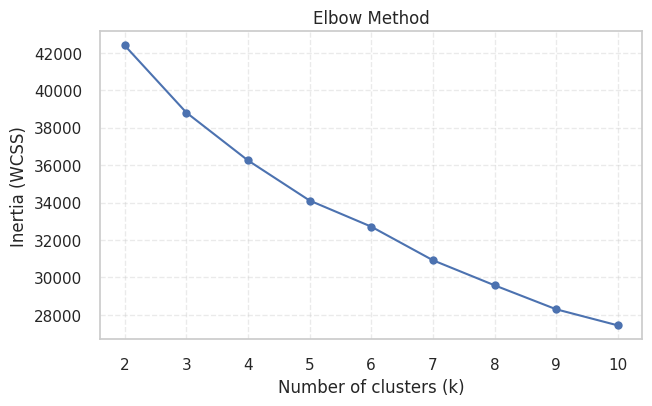

In [243]:
inertias = []
K = range(2, 11)

for k in K:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(scaled_data)
  inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

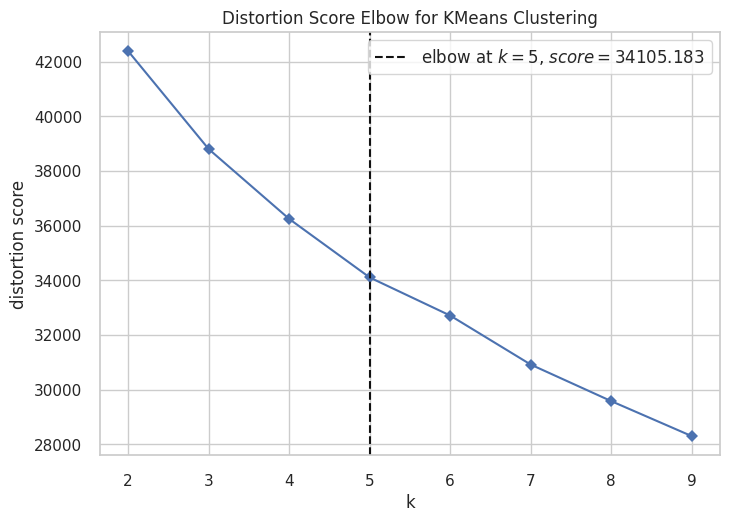

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [244]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42, n_init=10)
viz = KElbowVisualizer(model, k=(2,10), timings=False)
viz.fit(scaled_data)
viz.show()

##### **Observations:**
- The elbow plots show a clear bend around k = 5
- After k = 5, the inertia/distortion score decreases more slowly, meaning extra clusters do not add much value
- Therefore, the appropriate number of clusters is 5 for this dataset.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

In [245]:
scores = {}
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    scores[k] = score
    print(f"Silhouette score for k={k}: {score:.3f}")

Silhouette score for k=2: 0.254
Silhouette score for k=3: 0.180
Silhouette score for k=4: 0.179
Silhouette score for k=5: 0.187
Silhouette score for k=6: 0.191
Silhouette score for k=7: 0.193


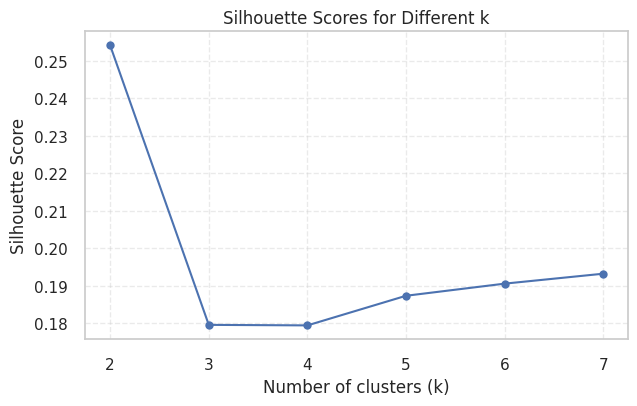

In [246]:
plt.figure(figsize=(7,4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

##### **Observations:**
- The silhouette score is highest at k = 2 (~0.25), and then drops significantly for k >= 3.

- However, the elbow method suggested k = 5 as a reasonable trade-off point.
  
  This means the two methods give different recommendations:

    - Silhouette favors k = 2 (better separation, but very coarse grouping).

    - Elbow favors k = 5 (more granular segmentation, still reasonable compactness).

- Since the business goal is to identify distinct customer segments rather than only a binary split, k = 5 is more useful despite a slightly lower silhouette score.

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [247]:
# --- prep (robust) ---
num_df = data.select_dtypes(include=[np.number]).copy()
for col in ['ID','Z_CostContact','Z_Revenue']:
  if col in num_df.columns:
    num_df.drop(columns=col, inplace=True)

In [248]:
# impute NaNs with median (KMeans can't handle NaN)
num_df = num_df.fillna(num_df.median(numeric_only=True))

In [249]:
# scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

In [250]:
import time
# --- final fit with k = 5 + timing ---
k = 5
t0 = time.perf_counter()
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_data)
fit_time = time.perf_counter() - t0

In [251]:
# 5) Attach cluster labels back to main data
data['Cluster'] = labels

In [252]:
print(f"Fit time (k={k}): {fit_time:.4f} seconds")
print(f"Inertia: {kmeans.inertia_:.2f}")
print("Cluster sizes:\n", data['Cluster'].value_counts().sort_index())
print(f"Silhouette score (k={k}): {silhouette_score(scaled_data, labels):.3f}")

Fit time (k=5): 0.0830 seconds
Inertia: 34105.18
Cluster sizes:
 Cluster
0    452
1    998
2    169
3     21
4    600
Name: count, dtype: int64
Silhouette score (k=5): 0.187


##### **Observations:**
1. Fit time: The model converged very quickly (~0.08 seconds), showing that K-Means is computationally efficient on this dataset.

2. Inertia: The within-cluster sum of squares is 34,105.18, indicating reasonable compactness of clusters.

3. Cluster sizes:
  - Cluster 0: 452 customers
  - Cluster 1: 998 customers (largest group)
  - Cluster 2: 169 customers
  - Cluster 3: 21 customers (very small, niche segment)
  - Cluster 4: 600 customers. The distribution is unbalanced, with some large clusters and one very small group.

4. Silhouette score: The value of 0.187 suggests moderate separation between clusters. This is common in real-world customer data, where segments overlap but still show distinct behavioral patterns.

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

In [253]:
# 0) Ensure we have cluster labels; if not, create them with k=5
if 'Cluster' not in data.columns:
  # numeric selection
  num_df = data.select_dtypes(inlcude=[np.number]).copy()
  for col in ['ID', 'Z_CostContact', 'Z_Revenue']:
    if col in num_df.columns:
      num_df.drop(columns=col, inplace=True)

  # impute missing values (median) and scale
  num_df = num_df.fillna(num_df.median(numeric_only=True))
  scaler = StandardScaler()
  scaler_data = scaler.fit_transform(num_df)

  # KMeans fir (k=5 from elbow)
  kmeans = KMeans(n_clusters=5, random_state=42, n_init=10).fit(scaled_data)
  data['Cluster'] = kmeans.labels_

else:
  # if clusters already exits, still build num_df/scaled_data for standardized plotss below
  num_df = data.select_dtypes(include=[np.number]).copy()
  for col in ["ID", "Z_CostContact", "Z_Revenue", "Cluster"]:
    if col in num_df.columns:
      num_df.drop(columns=col, inplace=True)

  num_df = num_df.fillna(num_df.median(numeric_only=True))
  scaler = StandardScaler()
  scaled_data = scaler.fit_transform(num_df)


In [254]:
# 1) Columns to profile (concise but informative set)
profile_cols = [
    'Recency',
    'MntWines','MntMeatProducts','MntGoldProds',
    'NumWebPurchases','NumCatalogPurchases','NumStorePurchases',
    'Kidhome','Teenhomea'
]

In [255]:
profile_cols = [c for c in profile_cols if c in data.columns]  # guard

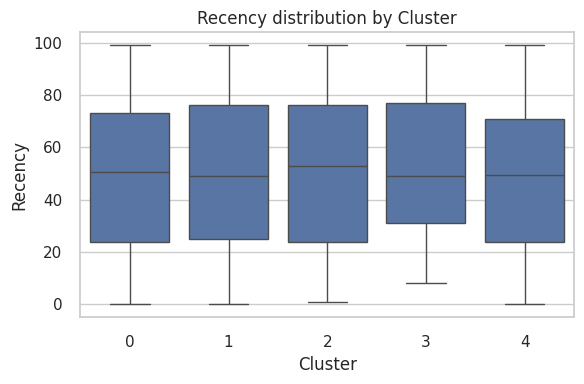

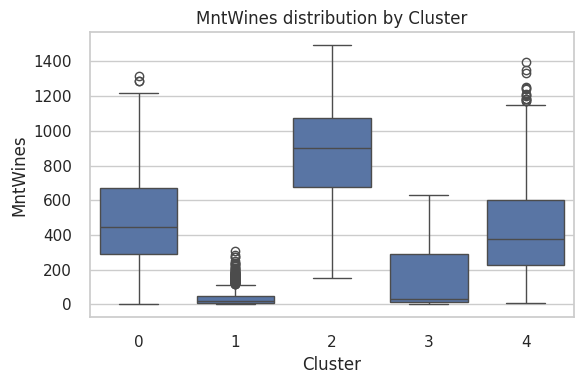

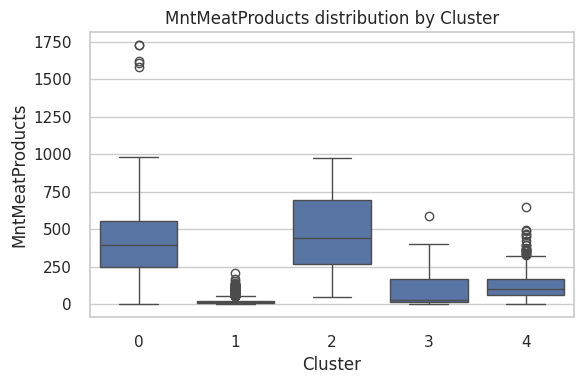

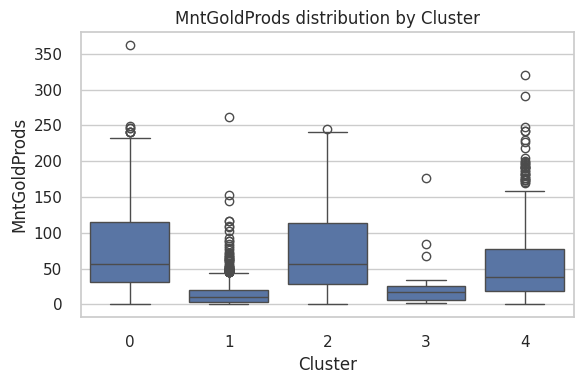

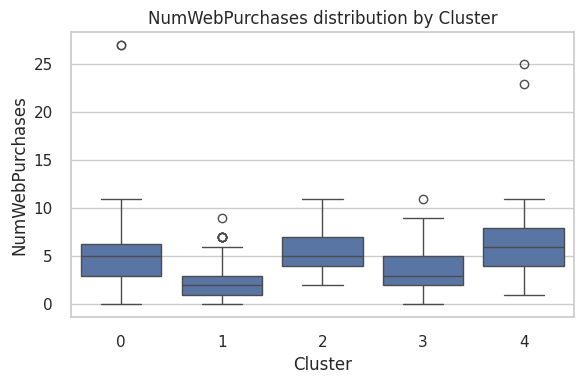

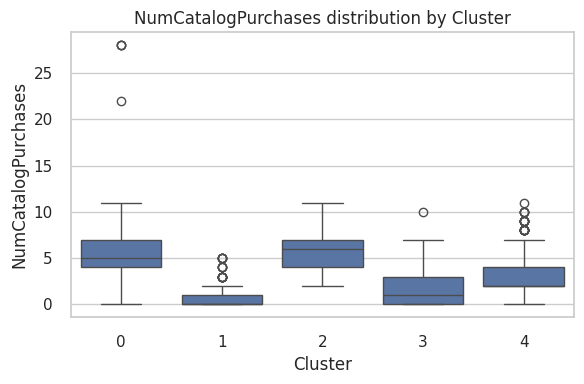

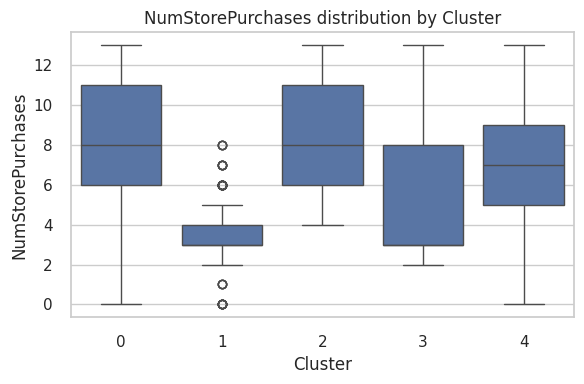

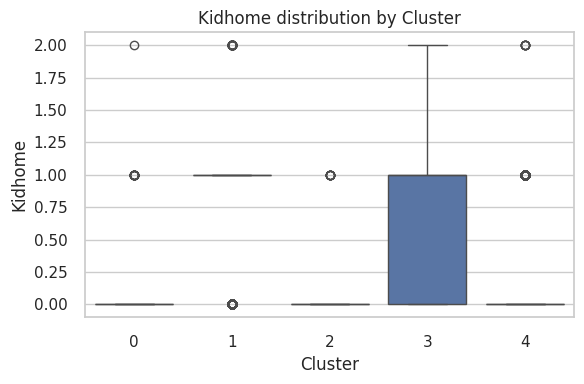

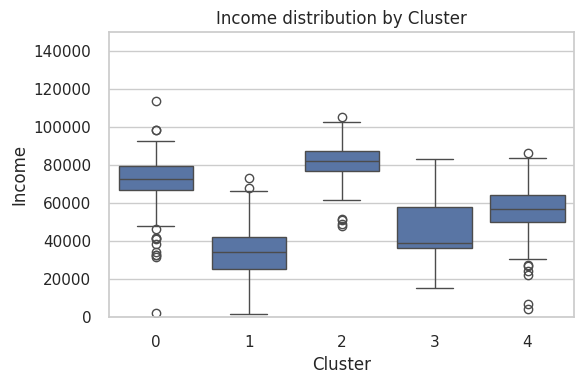

In [256]:
# 2) Boxplots per variable (raw scale)
for col in profile_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x='Cluster', y=col, data=data, whis=1.5)
  plt.title(f"{col} distribution by Cluster")
  plt.xlabel("Cluster"); plt.ylabel(col)
  plt.tight_layout()
  plt.show()

# For Income only
# Capped y-axis (e.g., to 150k) to avoid extreme outliers flattening the box
plt.figure(figsize=(6,4))
sns.boxplot(x='Cluster', y='Income', data=data, whis=1.5)
plt.ylim(0, 150000)  # adjust cap if needed
plt.title("Income distribution by Cluster")
plt.xlabel("Cluster"); plt.ylabel("Income")
plt.tight_layout()
plt.show()

In [257]:
# 3) Compact 2x2 grid with key varibles for the report

In [258]:
# standardized dataframe with the same columns
scaled_df = pd.DataFrame(scaled_data, columns=num_df.columns, index=data.index)
scaled_df['Cluster'] = data['Cluster']

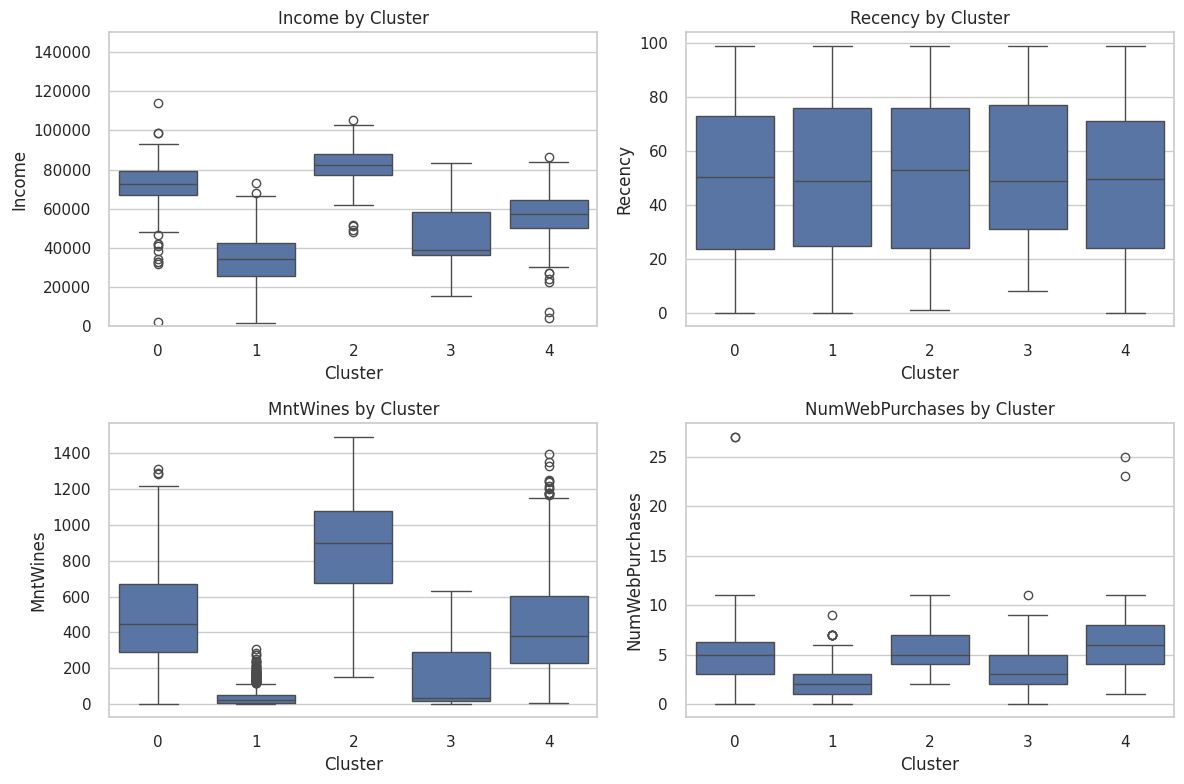

In [259]:
key_cols = ['Income','Recency','MntWines','NumWebPurchases']

plt.figure(figsize=(12,8))
for i, col in enumerate(key_cols, 1):
  plt.subplot(2, 2, i)
  sns.boxplot(x='Cluster', y=col, data=data, whis=1.5)
  if col == 'Income':      # cap axis for readability
      plt.ylim(0,150000)
      plt.title("Income by Cluster")
  else:
      plt.title(f"{col} by Cluster")
  plt.xlabel("Cluster"); plt.ylabel(col)
plt.tight_layout()
plt.show()


In [260]:
# Cluster Profiling Table

# 1) Select key variables for profiling
profile_vars = [
    'Income', 'Recency',
    'MntWines', 'MntMeatProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'Kidhome', 'Teenhome'
]

# 2) Compute mean values of each variable per cluster
#    This shows the typical profile of customers in each cluster
cluster_profile = data.groupby('Cluster')[profile_vars].mean().round(1)

# 3) Add cluster sizes (number of customers in each cluster)
cluster_profile['Cluster_Size'] = data['Cluster'].value_counts().sort_index()

# 4) Display the profiling table
display(cluster_profile)

,Income,Recency,MntWines,MntMeatProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Kidhome,Teenhome,Cluster_Size
Cluster,,,,,,,,,,,
0,73964.0,49.2,494.5,430.4,79.4,5.2,5.8,8.4,0.0,0.2,452
1,34691.6,49.5,39.0,22.7,15.1,2.1,0.5,3.2,0.8,0.4,998
2,81738.1,49.7,876.8,468.5,77.5,5.4,6.0,8.2,0.1,0.1,169
3,45242.3,53.0,169.0,112.5,27.5,3.6,2.0,5.2,0.7,0.5,21
4,56992.2,48.1,444.4,125.4,56.7,6.2,2.9,7.5,0.2,0.9,600


#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

In [261]:
# Choose key variables for profiling
profile_vars = [
    'Income','Recency',
    'MntWines','MntMeatProducts','MntGoldProds',
    'NumWebPurchases','NumCatalogPurchases','NumStorePurchases',
    'Kidhome','Teenhome'
]

In [262]:
# Compute average values per cluster
cluster_means = (
  data.groupby('Cluster')[profile_vars]
      .mean()
      .round(1)
      .reset_index()
)

In [263]:
order = sorted(cluster_means['Cluster'].unique())

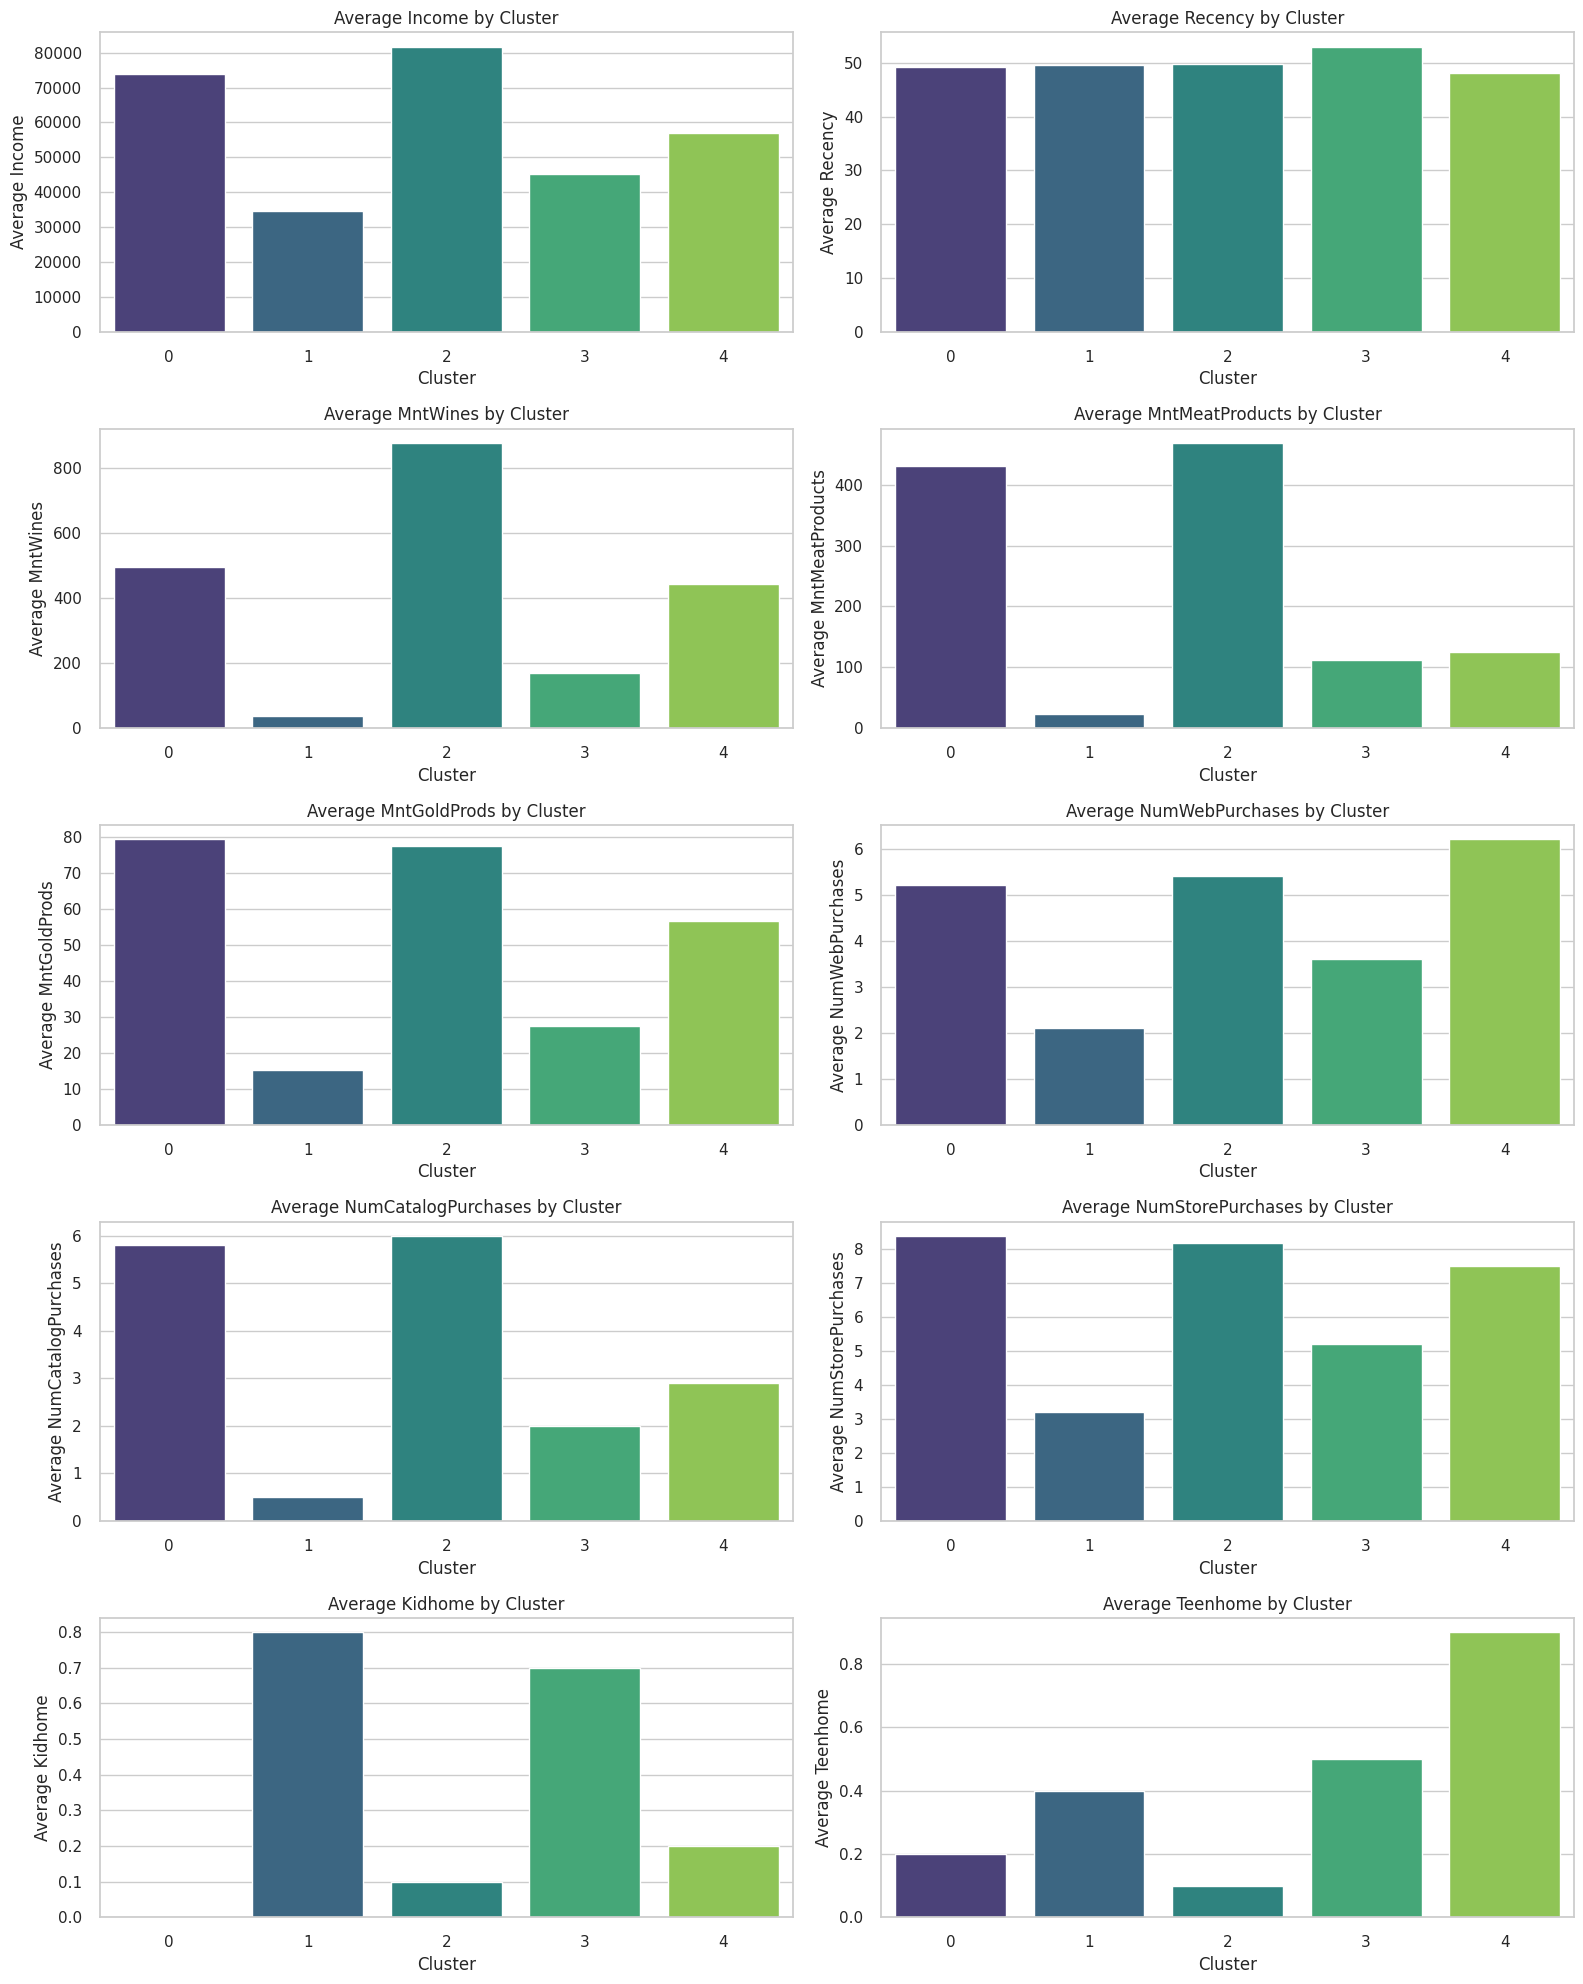

In [264]:
# Plot barplots for each variable
plt.figure(figsize=(16, 20))
for i, col in enumerate(profile_vars, 1):
    plt.subplot(5, 2, i)
    sns.barplot(
        x='Cluster', y=col, data=cluster_means,
        order=order, palette='viridis', errorbar=None
    )
    plt.title(f"Average {col} by Cluster")
    plt.xlabel("Cluster"); plt.ylabel(f"Average {col}")
    plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Q11_cluster_barplots.png", bbox_inches="tight", dpi=150)
plt.show()

##### **Observations:**
- **Cluster 0** (Affluent Traditionalists): This cluster has a high average income and high spending across various product categories, especially wine and meat. They also show a preference for store and catalog purchases over web purchases. They have a moderate number of kids and teens.

- **Cluster 1** (Low-income Minimal Spenders): This is the largest cluster with the lowest average income and minimal spending across all categories. They primarily use web purchases and have a higher number of kids at home compared to other clusters.

- **Cluster 2** (Premium Heavy Spenders): This cluster has the highest average income and the highest spending in almost all categories, particularly wine and meat. They are frequent purchasers across all channels (web, catalog, and store) and have a lower number of kids and teens.

- **Cluster 3** (Dormant Families): This is the smallest cluster, with a moderate income and relatively low spending. They have a higher number of kids at home and a moderate number of web visits per month. Their recency is slightly higher, suggesting they haven't purchased recently.

- **Cluster 4** (Digital-savvy Spenders): This cluster has a moderate to high income and high spending, especially on wine and gold products. They are characterized by a high number of web purchases and web visits. They have a higher number of teenagers compared to other clusters.
Płatne usługi Colab - Tutaj możesz anulować umowy


## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?



### Recomendation based on the cluster insights:

1. Cluster 0 – Affluent Traditionalists:
  - Targeted Marketing: Focus on personalized direct mail and catalog campaigns, given their preference for traditional channels.
  - Product Recommendations: Highlight premium wine, meat, and gold products in promotions.
  - Loyalty Programs: Offer exclusive benefits and in-store experiences to reinforce their loyalty to physical stores.

2. Cluster 1 – Low-income Minimal Spenders:
  - Value-Based Offers: Promote discounts, bundles, and budget-friendly alternatives to encourage purchases.
  - Digital Engagement: Utilize cost-effective digital channels for targeted ads and promotions.
  - Customer Retention: Focus on building brand loyalty through value and affordability rather than high-end experiences.

3. Cluster 2 – Premium Heavy Spenders:
  - VIP Programs: Implement exclusive VIP programs with early access to new products, personalized services, and special events.
  - Cross-selling: Recommend high-value products across all categories, leveraging their high spending across different channels.
  - Customer Relationship Management: Assign dedicated account managers or provide personalized support to nurture these high-value relationships.

4. Cluster 3 – Dormant Families:
  - Re-engagement Campaigns: Send targeted emails or offers to encourage them to return to the store or website.
  - Family-Focused Promotions: Offer discounts on products relevant to families with kids or teens.
  - Feedback Collection: Reach out to understand their reasons for decreased activity and address any issues.

5. Cluster 4 – Digital-savvy Spenders:
  - Digital Marketing: Invest in online advertising, social media campaigns, and personalized website experiences.
  - E-commerce Optimization: Ensure a seamless online shopping experience with easy navigation, mobile responsiveness, and efficient checkout processes.
  - Product Recommendations: Tailor online recommendations based on their browsing history and past purchases, especially for wine and gold products.

### Overall Recommendations:

Personalization: Leverage cluster insights to personalize marketing messages, product recommendations, and customer service interactions.
Channel Optimization: Allocate marketing budgets and resources based on the channel preferences of each cluster.
Customer Lifecycle Management: Develop targeted strategies for customer acquisition, retention, and reactivation based on cluster characteristics.
Data Monitoring: Continuously monitor customer behavior and cluster dynamics to adapt strategies as needed.